# 10 - Locality Sensitive Hashing (LSH)
---

In the previous notebook, we learned KDTree.

KDTree partitions space using trees.

But it struggles with high-dimensional embeddings.

Researchers explored another idea.

Instead of dividing space,

can we hash similar vectors into the same bucket?

This idea became **Locality Sensitive Hashing (LSH)**.

##  History

Traditional hash tables are designed for exact matching.

For example,

"apple"

always hashes to one bucket.

However,

vector search needs something different.

Researchers wanted **similar vectors** to have a high chance of landing in the same bucket.

This led to Locality Sensitive Hashing (LSH).

##  Think Like a Researcher

Imagine a school library.

Instead of checking every book,

books are placed into shelves.

When looking for an AI book,

you first go to the AI shelf.

LSH follows a similar idea.

Instead of searching every vector,

we search only vectors inside the same bucket.

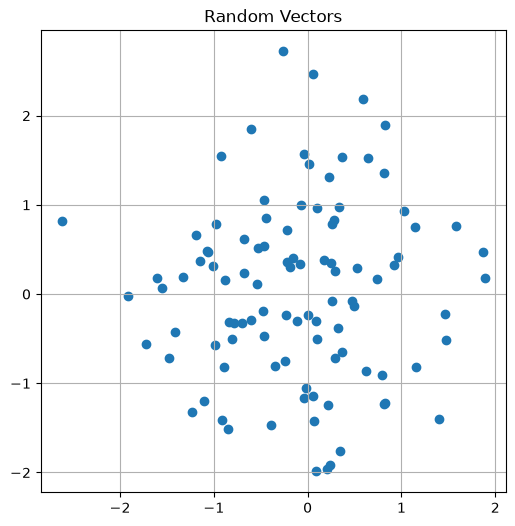

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

vectors = np.random.randn(100,2)

plt.figure(figsize=(6,6))
plt.scatter(vectors[:,0],vectors[:,1])
plt.grid()
plt.title("Random Vectors")
plt.show()

##  What is Hashing?

Hashing converts data into a bucket ID.

Example

```
Student 101

↓

Bucket 5
```

Traditional hashing is designed for **exact matching**.

LSH is designed for **similarity search**.

##  Random Hyperplane

LSH uses random lines (2D),

planes (3D),

or hyperplanes (higher dimensions)

to divide the space.

Vectors on the same side receive the same hash bit.

In [2]:
hyperplane = np.random.randn(2)

hyperplane

array([0.35778736, 0.56078453])

In [5]:
hash_bits=[]

for vector in vectors:

    value=np.dot(vector,hyperplane)

    if value>=0:
        hash_bits.append(1)
    else:
        hash_bits.append(0)

hash_bits[:20]

[1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0]

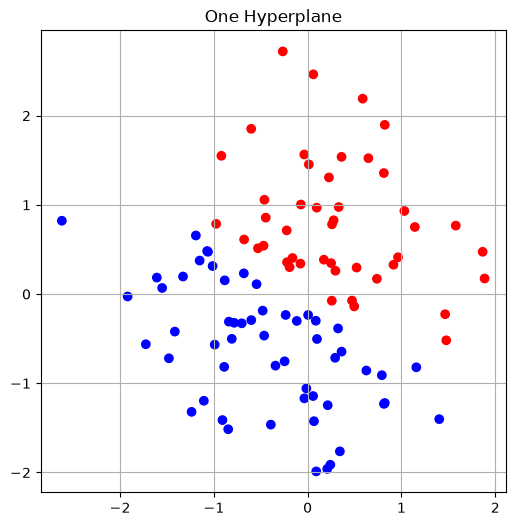

In [6]:
colors=["blue" if b==0 else "red" for b in hash_bits]

plt.figure(figsize=(6,6))

plt.scatter(
    vectors[:,0],
    vectors[:,1],
    c=colors
)

plt.grid()

plt.title("One Hyperplane")

plt.show()

## Observation

Points on one side

↓

Bucket 0

Points on the other side

↓

Bucket 1

Instead of checking every point,

we first choose the correct bucket.

In [7]:
hyperplanes=np.random.randn(4,2)

codes=[]

for vector in vectors:

    code=[]

    for plane in hyperplanes:

        bit=1 if np.dot(vector,plane)>=0 else 0

        code.append(bit)

    codes.append(code)

codes[:5]

[[1, 0, 1, 0], [1, 0, 1, 1], [0, 1, 0, 0], [1, 0, 1, 1], [1, 1, 1, 1]]

In [8]:
codes[:10]

[[1, 0, 1, 0],
 [1, 0, 1, 1],
 [0, 1, 0, 0],
 [1, 0, 1, 1],
 [1, 1, 1, 1],
 [0, 1, 0, 0],
 [0, 1, 0, 0],
 [0, 1, 0, 0],
 [0, 1, 0, 1],
 [0, 1, 0, 0]]

##  Bucketing

Vectors with identical or very similar hash codes

are stored in the same bucket.

During search,

only vectors inside that bucket are compared.

## Why is LSH Faster?

Flat Index

↓

Compare every vector

LSH

↓

Find bucket

↓

Search only inside bucket

↓

Return nearest neighbors

## Advantages

✅ Fast

✅ Scales well

✅ Good for approximate search

✅ Works better than KDTree for many high-dimensional datasets

## Limitations

❌ Approximate

❌ Similar vectors can sometimes fall into different buckets

❌ Performance depends on hash functions and parameters

##  Applications

LSH is used in:

- Near-duplicate document detection
- Image retrieval
- Audio fingerprinting
- Recommendation systems
- Large-scale similarity search

## Flat vs KDTree vs LSH

| Feature | Flat | KDTree | LSH |
|---------|------|--------|------|
| Search Type | Exact | Exact | Approximate |
| Speed | Slow | Fast (low dimensions) | Fast |
| High Dimensions | Expensive | Weak | Better |
| Search Method | Compare All | Partition Space | Hash Buckets |

##  Summary

Today I learned

- What LSH is
- Why normal hashing is not enough
- Random hyperplanes
- Binary hash codes
- Bucket-based search
- Advantages and limitations

##  Think Like a Researcher

LSH reduces the number of vectors we search.

But another challenge appears.

Suppose your vector database stores

100 million vectors,

each with

768 dimensions.

The vectors themselves consume a large amount of memory.

Researchers asked:

"Can we compress vectors without storing every value exactly?"

This idea became **Product Quantization (PQ)**.